In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# Data Exploration

Structural analysis of the real and simulated datasets, followed by cell-level clustering.

1. Real data — shape, temporal coverage, firing rates, covariate completeness, example trial  
2. Simulated data — structure and comparison with real data  
3. Cell clustering — correlation vs GLM features x KMeans vs hierarchical methods

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score as _silhouette_score

from src.get_data import load_data, get_cell_slice
from src.clustering_tools import run_clustering, cluster_report
from src.visualisation import (
    plot_covariate_trial,
    COVARIATE_NAMES_REAL,
    COVARIATE_NAMES_SIMULATED,
    _set_journal_style,
)

_set_journal_style()

## 1. Real Data

### 1.1 Structure

In [3]:
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/real_data.mat")

n_features, n_bins = X.shape
unique_cells, bins_per_cell = np.unique(cell_ids, return_counts=True)
unique_recs, bins_per_rec = np.unique(rec_ids, return_counts=True)
n_cells = len(unique_cells)
n_recs = len(unique_recs)

nan_per_cov = np.isnan(X).sum(axis=1)
nan_pct_cov = 100 * nan_per_cov / n_bins

print(f"{'Array shape':<28} X: {X.shape},  Y: {Y.shape}")
print(f"{'Covariates':<28} {n_features}")
print(f"{'Total time bins':<28} {n_bins:,}")
print(f"{'Cells':<28} {n_cells}  (IDs {unique_cells.min()}-{unique_cells.max()})")
print(f"{'Recordings':<28} {n_recs}")
print(f"{'Bins/cell (range)':<28} {bins_per_cell.min():,}-{bins_per_cell.max():,}")
print(f"{'Spike count range':<28} {int(Y.min())}-{int(Y.max())}")
print(f"{'NaN in Y':<28} {int(np.isnan(Y).sum())}")
print(f"{'Covariates with NaN':<28} {int((nan_per_cov > 0).sum())} of {n_features}")

Array shape                  X: (14, 1657180),  Y: (1657180,)
Covariates                   14
Total time bins              1,657,180
Cells                        247  (IDs 1-247)
Recordings                   5
Bins/cell (range)            6,230-7,000
Spike count range            0-21
NaN in Y                     0
Covariates with NaN          0 of 14


### 1.2 Temporal Coverage

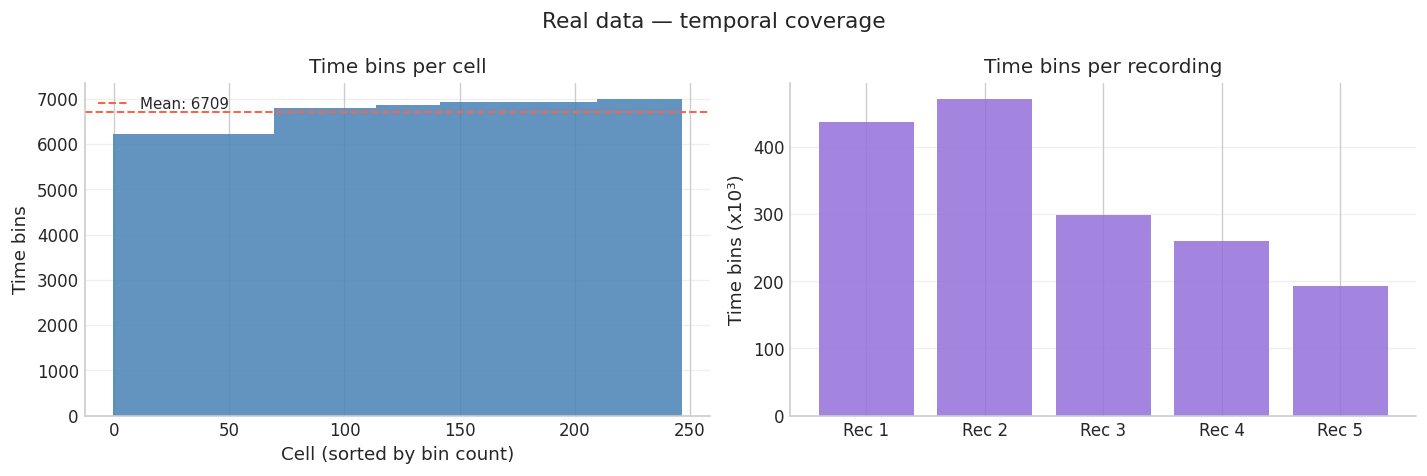

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bins per cell
axes[0].bar(
    range(n_cells), np.sort(bins_per_cell), width=1.0, color="steelblue", alpha=0.85
)
axes[0].axhline(
    bins_per_cell.mean(),
    color="tomato",
    linestyle="--",
    linewidth=1.2,
    label=f"Mean: {bins_per_cell.mean():.0f}",
)
axes[0].set_xlabel("Cell (sorted by bin count)")
axes[0].set_ylabel("Time bins")
axes[0].set_title("Time bins per cell")
axes[0].legend(fontsize=9)

# Bins per recording
axes[1].bar(
    [f"Rec {r}" for r in unique_recs],
    bins_per_rec / 1000,
    color="mediumpurple",
    alpha=0.85,
)
axes[1].set_ylabel("Time bins (x10³)")
axes[1].set_title("Time bins per recording")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Real data — temporal coverage", fontsize=13)
fig.tight_layout()
plt.show()

### 1.3 Spike Count Distribution

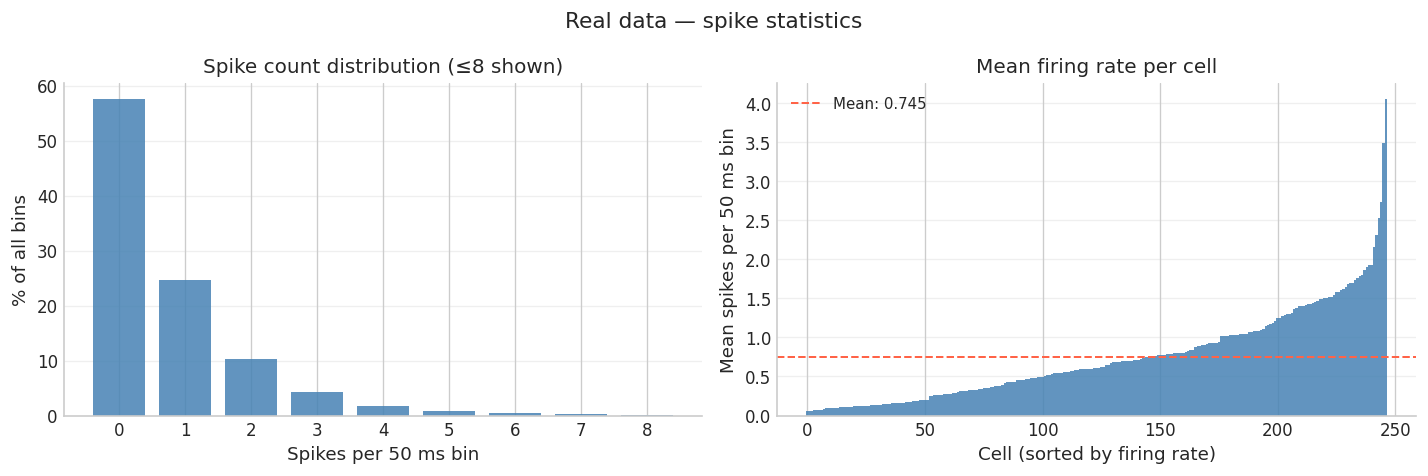

Sparsity:       57.6% of bins are silent
Firing rate:    0.0574-4.0591 spk/bin (range across cells)


In [5]:
mean_rates = np.array([Y[get_cell_slice(c, cell_ids)].mean() for c in unique_cells])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Spike count histogram (cap at 8 for readability)
spike_vals, spike_counts = np.unique(Y[Y <= 8].astype(int), return_counts=True)
axes[0].bar(spike_vals, 100 * spike_counts / n_bins, color="steelblue", alpha=0.85)
axes[0].set_xlabel("Spikes per 50 ms bin")
axes[0].set_ylabel("% of all bins")
axes[0].set_title("Spike count distribution (≤8 shown)")
axes[0].set_xticks(spike_vals)

# Mean firing rate per cell — sorted
axes[1].bar(
    range(n_cells), np.sort(mean_rates), width=1.0, color="steelblue", alpha=0.85
)
axes[1].axhline(
    mean_rates.mean(),
    color="tomato",
    linestyle="--",
    linewidth=1.2,
    label=f"Mean: {mean_rates.mean():.3f}",
)
axes[1].set_xlabel("Cell (sorted by firing rate)")
axes[1].set_ylabel("Mean spikes per 50 ms bin")
axes[1].set_title("Mean firing rate per cell")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Real data — spike statistics", fontsize=13)
fig.tight_layout()
plt.show()

print(f"Sparsity:       {100 * (Y == 0).mean():.1f}% of bins are silent")
print(
    f"Firing rate:    {mean_rates.min():.4f}-{mean_rates.max():.4f} spk/bin (range across cells)"
)

### 1.4 Covariate Completeness

3D tracking covariates (indices 0–4) may have NaN values due to tracking failures. These are imputed from training data only inside `prepare_cellwise_datasets`.

In [6]:
cov_df = pd.DataFrame(
    {
        "Covariate": COVARIATE_NAMES_REAL,
        "NaN %": nan_pct_cov.round(2),
        "Min": np.nanmin(X, axis=1).round(4),
        "Max": np.nanmax(X, axis=1).round(4),
        "Mean": np.nanmean(X, axis=1).round(4),
        "Std": np.nanstd(X, axis=1).round(4),
    }
)
print(cov_df.to_string(index=False))

         Covariate  NaN %     Min     Max    Mean    Std
        Tilt angle    0.0  0.0000 10.0000  0.6259 0.9791
aPM (ang. passive)    0.0  0.0007 10.0000  0.6611 0.9636
lPM (lin. passive)    0.0  0.0000 10.0000  0.4247 0.9978
 aAM (ang. active)    0.0  0.0009  5.1176  0.5113 1.0001
 lAM (lin. active)    0.0 -2.3743  1.8917 -0.1518 1.2381
          Sin(Ori)    0.0 -1.9089  1.9089 -0.2350 1.0365
          Cos(Ori)    0.0  0.0000  6.2649  2.9933 1.4611
           DistRot    0.0 -4.1246  0.6174 -0.3391 1.0000
             TiltL    0.0 -1.0627  4.2441  0.3059 1.0001
             TiltR    0.0  0.0000  0.0000  0.0000 0.0000
                ON    0.0  0.0000  0.0000  0.0000 0.0000
           ON_fast    0.0  0.0000  0.0000  0.0000 0.0000
          OFF_fast    0.0  0.0000  0.0000  0.0000 0.0000
           ON_slow    0.0  0.0000  0.0000  0.0000 0.0000


### 1.5 Example Trial

Cell 6, trial 60. Cell 6 has the highest pseudo-R² in batch 0 and trial 60 is well into the session where motion events occur.

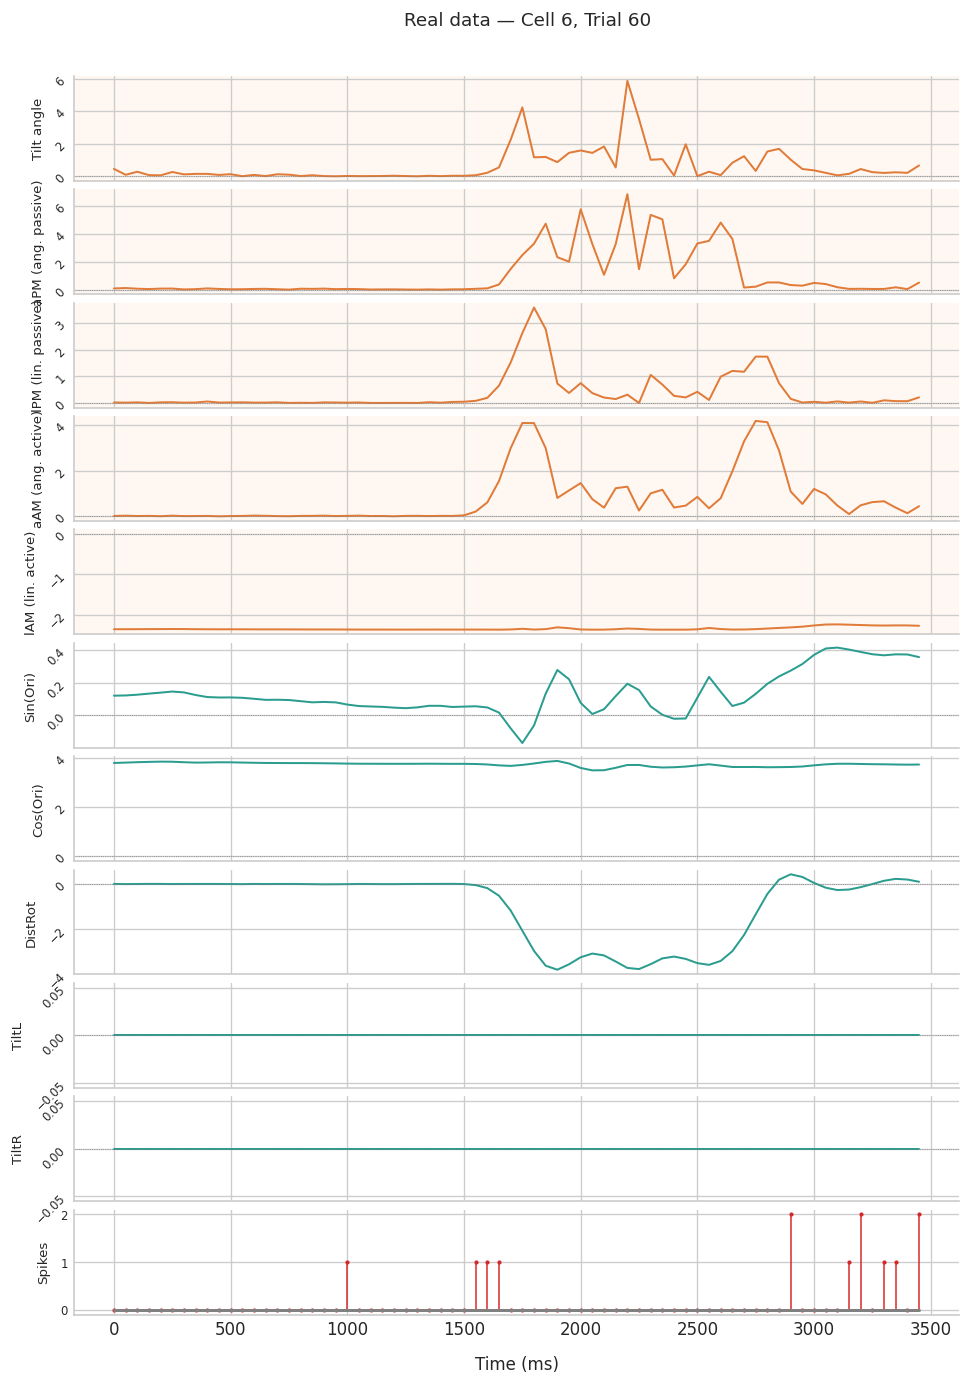

In [23]:
plot_covariate_trial(
    X,
    Y,
    cell_ids,
    cell_idx=6,
    trial_idx=60,
    covariate_names=COVARIATE_NAMES_REAL,
    trials_per_cell=89,
    bin_duration_ms=50,
    show_only_indices=list(range(10)),
    figsize=(9, 12),
    title="Real data — Cell 6, Trial 60",
)

## 2. Simulated Data

### 2.1 Structure

Four synthetic recordings (`test1–4.mat`) used for end-to-end pipeline validation before training on real data.

In [8]:
SIM_DIR = "../resources/data/simulated"
SIM_FILES = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]

Xs, Ys, cids_s, rids_s = load_data(SIM_DIR, SIM_FILES)

unique_cells_s, bins_per_cell_s = np.unique(cids_s, return_counts=True)
unique_recs_s, bins_per_rec_s = np.unique(rids_s, return_counts=True)
mean_rates_s = np.array([Ys[get_cell_slice(c, cids_s)].mean() for c in unique_cells_s])

print(f"{'Array shape':<28} X: {Xs.shape},  Y: {Ys.shape}")
print(f"{'Covariates':<28} {Xs.shape[0]}")
print(f"{'Total time bins':<28} {Ys.shape[0]:,}")
print(f"{'Cells':<28} {len(unique_cells_s)}")
print(f"{'Recordings':<28} {len(unique_recs_s)}")
print(f"{'Bins/cell':<28} {bins_per_cell_s.min():,}-{bins_per_cell_s.max():,}")
print(f"{'Spike count range':<28} {int(Ys.min())}-{int(Ys.max())}")
print(f"{'Sparsity':<28} {100 * (Ys == 0).mean():.1f}% silent bins")
print(
    f"{'Firing rate range':<28} {mean_rates_s.min():.4f}-{mean_rates_s.max():.4f} spk/bin"
)

Array shape                  X: (5, 60000),  Y: (60000,)
Covariates                   5
Total time bins              60,000
Cells                        20
Recordings                   4
Bins/cell                    3,000-3,000
Spike count range            0-100
Sparsity                     62.6% silent bins
Firing rate range            0.4103-5.0423 spk/bin


### 2.2 Comparison with Real Data

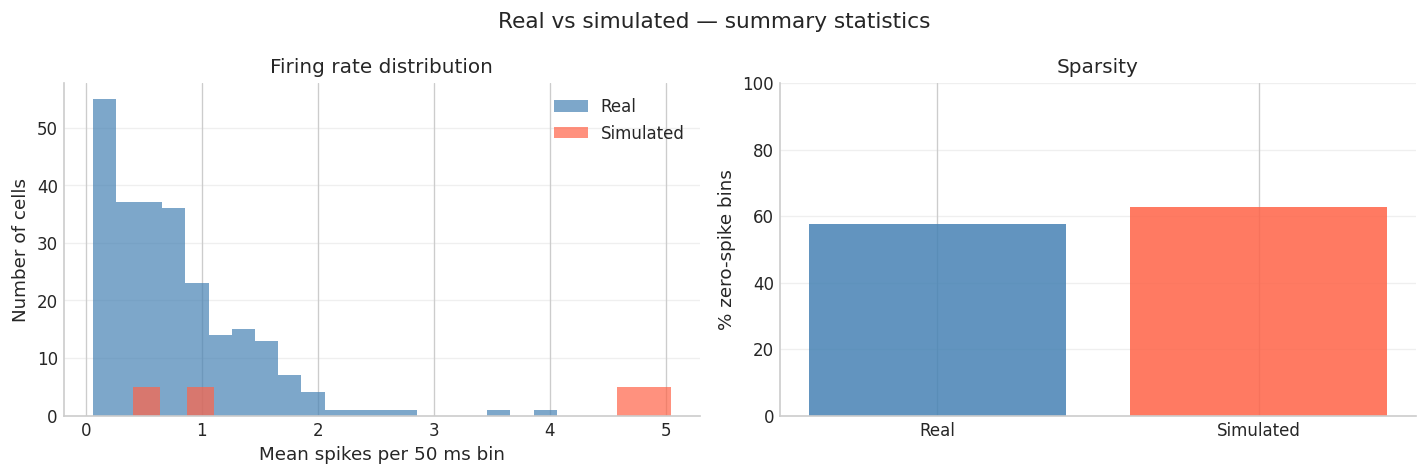

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Firing rate distribution
axes[0].hist(mean_rates, bins=20, alpha=0.7, label="Real", color="steelblue")
axes[0].hist(mean_rates_s, bins=20, alpha=0.7, label="Simulated", color="tomato")
axes[0].set_xlabel("Mean spikes per 50 ms bin")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Firing rate distribution")
axes[0].legend()

# Sparsity
axes[1].bar(
    ["Real", "Simulated"],
    [100 * (Y == 0).mean(), 100 * (Ys == 0).mean()],
    color=["steelblue", "tomato"],
    alpha=0.85,
)
axes[1].set_ylabel("% zero-spike bins")
axes[1].set_ylim(0, 100)
axes[1].set_title("Sparsity")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Real vs simulated — summary statistics", fontsize=13)
fig.tight_layout()
plt.show()

## 3. Cell Clustering (Real Data)

Two feature representations × two clustering algorithms give four combinations. Silhouette scores are compared to identify the most separable grouping.

| Feature | Description |
|---|---|
| **Correlation** | Pearson correlation between each cell's spike train and each covariate |
| **GLM weights** | Fitted Poisson GLM coefficients per cell |

| Method | Description |
|---|---|
| **KMeans** | Partition-based, minimises within-cluster variance |
| **Hierarchical** | Agglomerative clustering with Ward linkage |

In [10]:
N_CLUSTERS = 4

configs = [
    ("correlation", "kmeans", "Correlation x KMeans"),
    ("correlation", "hierarchical", "Correlation x Hierarchical"),
    ("glm", "kmeans", "GLM weights x KMeans"),
    ("glm", "hierarchical", "GLM weights x Hierarchical"),
]

clustering_results = {}
for feat_key, clust_key, label in configs:
    print(f"Running: {label}")
    res = run_clustering(
        X,
        Y,
        cell_ids,
        rec_ids,
        feature_key=feat_key,
        cluster_key=clust_key,
        n_clusters=N_CLUSTERS,
        title_prefix=label,
        show_report=False,
    )
    score = _silhouette_score(res["scaled_features"], res["labels"])
    clustering_results[label] = {**res, "silhouette_score": score}
    print(f"  silhouette = {score:.4f}")

Running: Correlation x KMeans


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [ 9 10 11 12 13]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


  silhouette = 0.2223
Running: Correlation x Hierarchical


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [ 9 10 11 12 13]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


  silhouette = 0.2488
Running: GLM weights x KMeans
  silhouette = 0.1082
Running: GLM weights x Hierarchical
  silhouette = 0.4045


             Configuration  Silhouette score   Cluster sizes
GLM weights x Hierarchical            0.4045    4, 231, 9, 3
Correlation x Hierarchical            0.2488 63, 25, 29, 130
      Correlation x KMeans            0.2223 101, 70, 55, 21
      GLM weights x KMeans            0.1082 77, 100, 59, 11


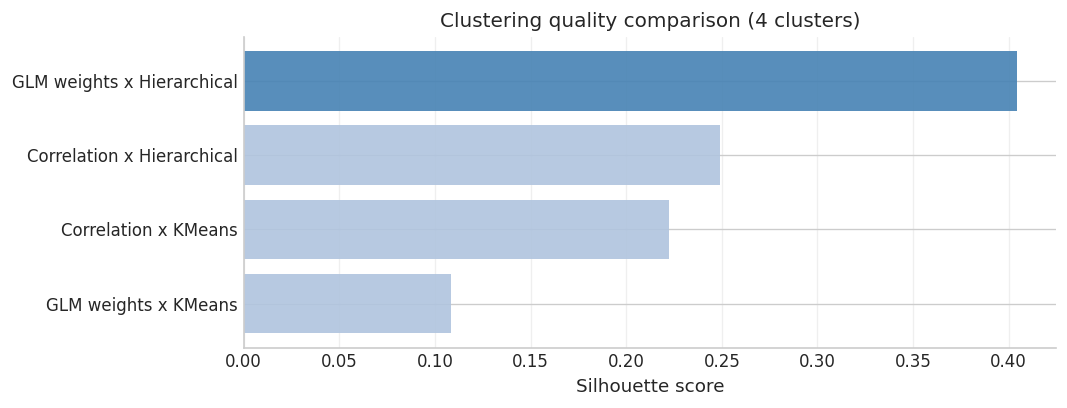

In [11]:
rows = []
for feat_key, clust_key, label in configs:
    res = clustering_results[label]
    sizes = pd.Series(res["labels"]).value_counts().sort_index()
    rows.append(
        {
            "Configuration": label,
            "Silhouette score": round(res["silhouette_score"], 4),
            "Cluster sizes": ", ".join(str(s) for s in sizes.values),
        }
    )

summary_df = (
    pd.DataFrame(rows)
    .sort_values("Silhouette score", ascending=False)
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.5))
colours = ["steelblue" if i == 0 else "lightsteelblue" for i in range(len(summary_df))]
ax.barh(
    summary_df["Configuration"][::-1],
    summary_df["Silhouette score"][::-1],
    color=colours[::-1],
    alpha=0.9,
)
ax.set_xlabel("Silhouette score")
ax.set_title(f"Clustering quality comparison ({N_CLUSTERS} clusters)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

Best: GLM weights x Hierarchical  (silhouette = 0.4045)


GLM weights x Hierarchical report:
Cluster 2: cells [1, 2, 3, 4, 5, 6, 7, 8, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 2

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


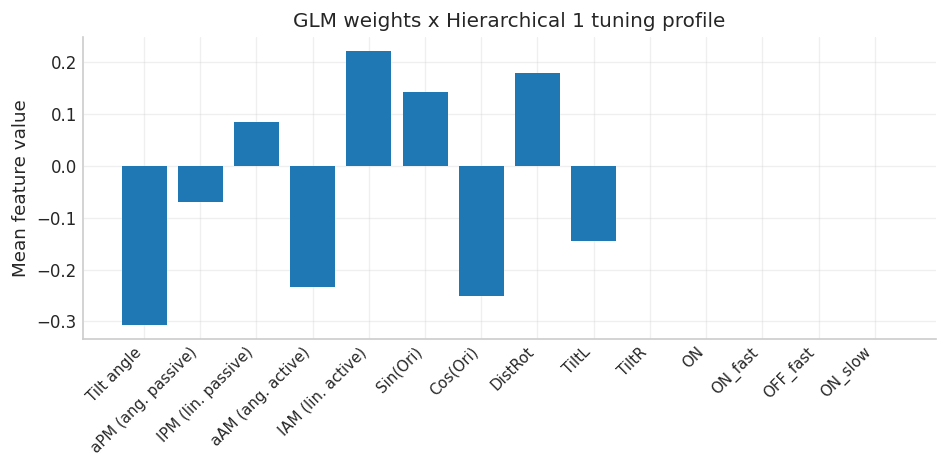

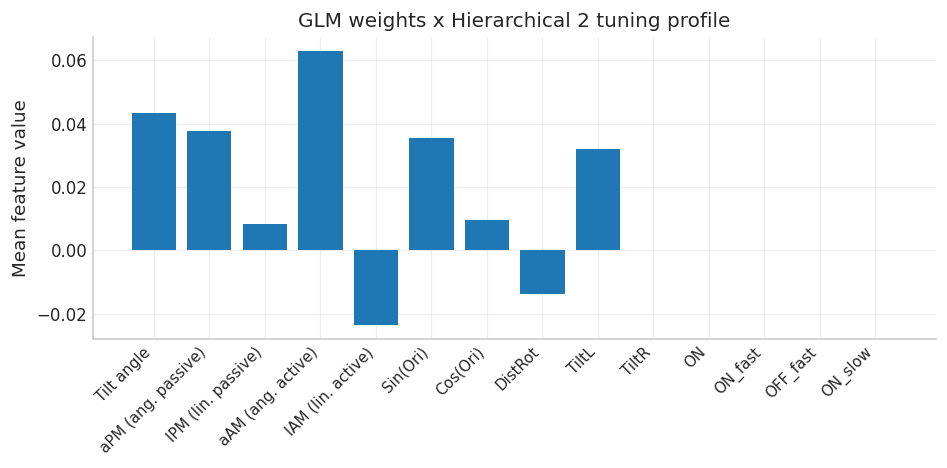

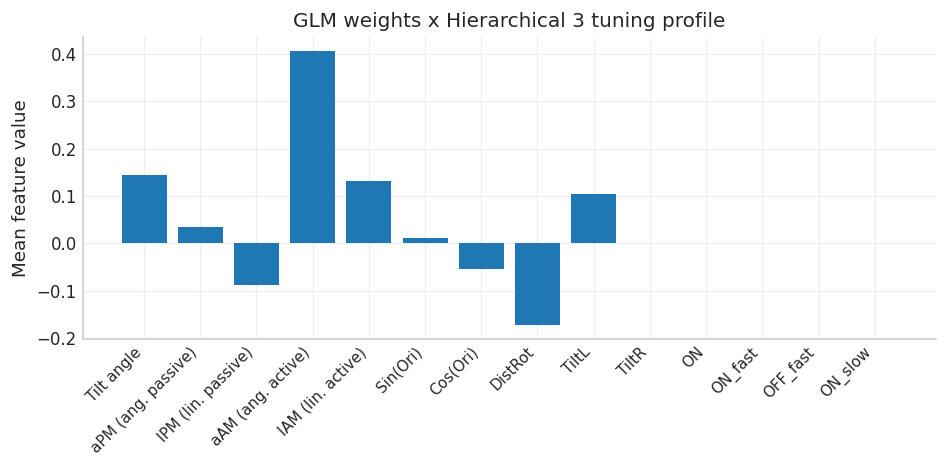

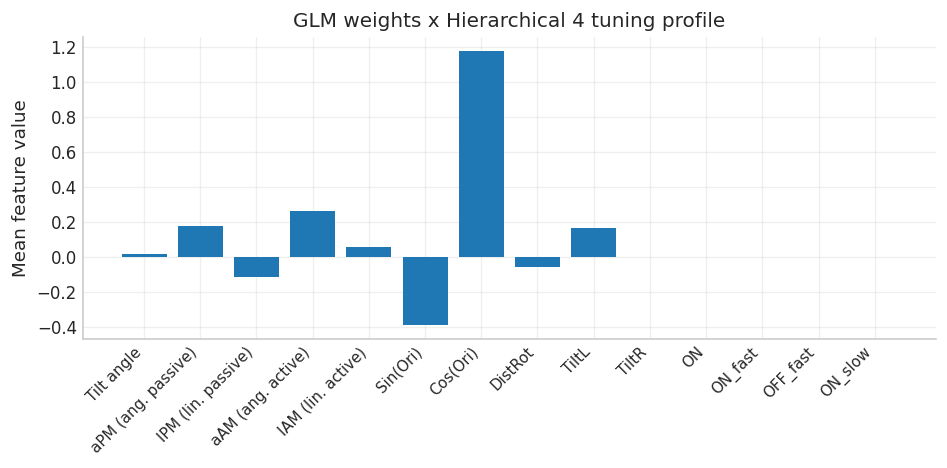

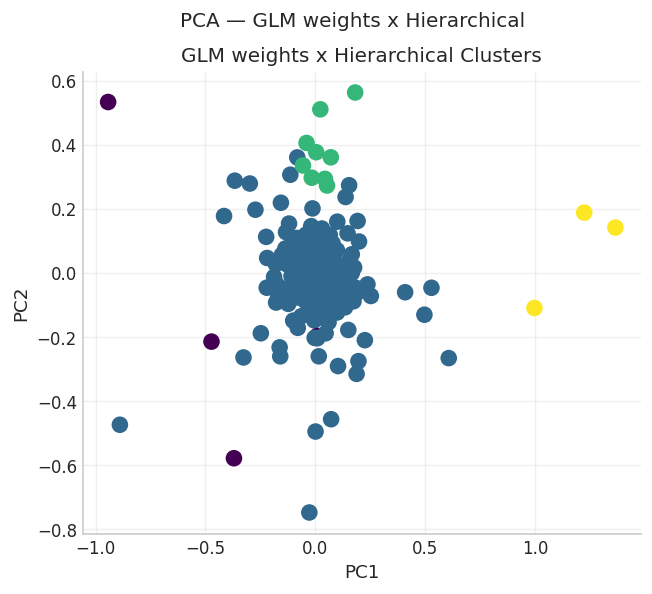

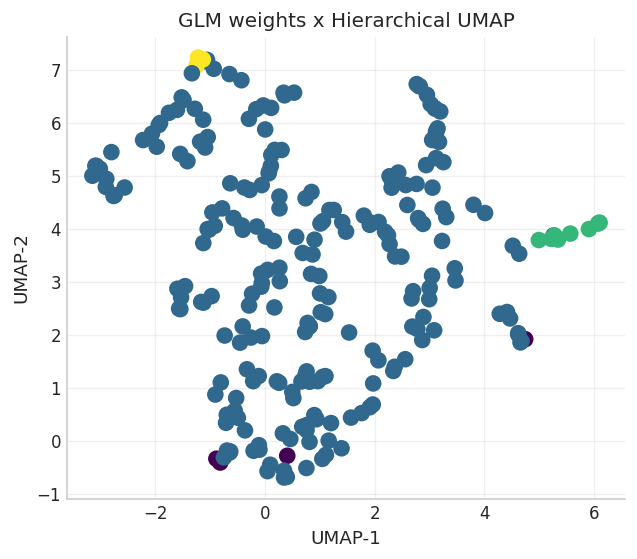


Suggested functional labels:
  Cluster 1 (4 cells): Strongly tuned to Tilt angle (negative)
  Cluster 2 (231 cells): Strongly tuned to aAM (ang. active) (positive)
  Cluster 3 (9 cells): Strongly tuned to aAM (ang. active) (positive)
  Cluster 4 (3 cells): Strongly tuned to Cos(Ori) (positive)


In [12]:
best_label = summary_df.iloc[0]["Configuration"]
best = clustering_results[best_label]
print(f"Best: {best_label}  (silhouette = {best['silhouette_score']:.4f})\n")

report = cluster_report(
    best["features"],
    best["labels"],
    cell_ids,
    title_prefix=best_label,
    covariate_names=COVARIATE_NAMES_REAL,
)

report["pca_figure"].suptitle(f"PCA — {best_label}", fontsize=12)
plt.show()

report["umap_figure"].suptitle(f"UMAP — {best_label}", fontsize=12)
plt.show()

print("\nSuggested functional labels:")
membership_series = pd.Series(report["membership"])
sizes = membership_series.value_counts().sort_index()
for cluster_id, func_label in report["suggested_labels"].items():
    n = sizes.get(cluster_id, 0)
    print(f"  Cluster {cluster_id} ({n} cells): {func_label}")